# ANOVA DE UN FACTOR

Supongamos que somos Científicos de Datos en una empresa de comercio electrónico y el equipo de mercadeo quiere evaluar si diferentes estrategias de email marketing influyen en la tasa de conversión. 

La idea es probar tres campañas distintas de marketing y en cada caso medir la tasa de conversión (%) por usuario:

- Campaña A: correo con descuento del 10%
- Campaña B: correo con envío gratis
- Campaña C: correo con reseñas de clientes

**¿Hay diferencias en la tasa media de conversión entre las tres campañas?**

## 1. Desarrollo de la prueba de hipótesis

Se trata de una prueba ANOVA de 1 factor porque:

- Tendremos un factor que será la campaña
- Este factor tendrá tres niveles (A, B y C) y queremos determinar si existen diferencias entre las tasas de conversión entre las tres campañas

### 1.1. Paso 1: definir el problema del negocio

> **¿Hay diferencias en la tasa media de conversión entre las tres campañas?**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿Existen diferencias estadísticamente significativas en las tasas medias de conversión entre las tres campañas?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

- $H_0$: las medias de las tasas de conversión en las tres campañas son iguales
- $H_1$: las medias de las tasas de conversión en las tres campañas son diferentes

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$. Y recordemos que en ANOVA **siempre tendremos una prueba unilateral derecha**-

Aún no dibujaremos la distribución F pues esta depende de los grados de libertad.

### 1.5. Paso 5: definir la potencia de la prueba ($1-\beta$) y el tamaño de las muestras ($n$)

Seguiremos la misma lógica usada en lecciones. Es decir:

1. Definimos el tamaño del efecto esperado
2. Definimos la potencia de la prueba esperada (probabilidad entre 0 y 1)
3. Usamos "FTestAnovaPower" de "Scipy" para calcular el tamaño de las muestras. **Este módulo está especialmente diseñado para pruebas ANOVA**

En el caso de la prueba ANOVA el tamaño del efecto se define de manera diferente. En primer lugar se define el factor eta cuadrado ($\eta^2$):

$$\eta^2 = \frac{\text{suma de cuadrados entre grupos}}{\text{suma de cuadrados en la totalidad de los datos}}$$

Así:

- Si la suma de cuadrados entre grupos es "grande" la mayor parte de la variación en los datos será debida precisamente a las diferencias entre grupos y por tanto el tamaño del efecto (es decir las diferencias entre grupos) serán grandes.
- Pero si la suma de cuadrados entre grupos es "pequeña" la variación en los datos no será debida a las diferencias entre grupos y por tanto el tamaño del efecto será pequeño.

Y habiendo definido $\eta^2$ definimos el tamaño del efecto f de Cohen:

$$f=\sqrt{\frac{\eta^2}{1-\eta^2}}$$

Así:

- Si $\eta^2 \rightarrow 0$ entonces $f \rightarrow 0$ y se tendrá un tamaño del efecto "pequeño"
- Y si $\eta^2 \rightarrow 1$ entonces $f \rightarrow \text{"grande"}$ y se tendrá un tamaño del efecto "grande"

En la práctica estos son los rangos propuestos por Cohen:

- 0.10: tamaño del efecto pequeño
- 0.25: tamaño del efecto mediano
- 0.40: tamaño del efecto grande

Por otra parte, la potencia de la prueba tiene exactamente el mismo significado que en las pruebas anteriores (y por tanto será un valor entre 0 y 1).

Así que veamos cómo calcular el tamaño mínimo de las muestras usando "FTestAnovaPower":

In [1]:
from statsmodels.stats.power import FTestAnovaPower

# Diseño del experimento
f = 0.4         # Esperamos obtener un tamaño del efecto grande
alpha = 0.05    # Nivel de significancia
power = 0.9     # Potencia esperada para la prueba
Ng = 3          # Número de grupos, que corresponde a los subniveles del factor (tipo de campaña)

# Instancia de FTestAnovaPower
analisis = FTestAnovaPower()

# Cálculo del número de muestras por grupo
n = analisis.solve_power(
    effect_size=f,
    alpha=alpha, 
    power=power, 
    k_groups=Ng
)
print(f"Tamaño mínimo de la muestra por cada grupo: {n}")

Tamaño mínimo de la muestra por cada grupo: 82.16474744262408


Es decir que:

> **Necesitamos recolectar al menos 83 muestras por grupo (83 usuarios) para tener un tamaño del efecto esperado de 0.4, un nivel de significancia de 0.05 y una potencia de la prueba de 0.9**

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que ya hemos recolectado los datos. Estos se encuentran en el dataset "campañas_tasas_conversion.csv":

In [2]:
import pandas as pd

datos = pd.read_csv('campañas_tasas_conversion.csv')
datos

,campaña,tasa_conversión
0,A,3.4
1,A,2.9
2,B,3.3
3,A,4.1
4,B,3.3
...,...,...
605,C,2.9
606,B,3.3
607,B,4.2
608,A,2.3


Este dataset ya se encuentra en el formato requerido por "pingouin" para realizar la prueba ANOVA. En particular:

- La columna "campaña" contiene los niveles (A, B, C) a los que pertenece cada dato
- La columna "tasa_conversión" contiene las observaciones hechas para cada usuario

Hagamos una breve exploración de los datos. Hagamos inicialmente un conteo de cuántos usuarios tendremos en cada agrupación:

In [3]:
conteos = datos['campaña'].value_counts()
conteos

campaña
B    205
A    203
C    202
Name: count, dtype: int64

Y vemos que en todos los casos tendremos más de las 83 muestras mínimas que estimamos anteriormente.

Veamos las medias de las tasas de conversión por cada tipo de campaña:

In [4]:
datos.groupby(by='campaña')['tasa_conversión'].mean()

campaña
A    3.110345
B    3.311707
C    2.964356
Name: tasa_conversión, dtype: float64

Vemos que numéricamente las tasas de conversión son relativamente diferentes y la idea es usar precisamente ANOVA de 1 factor para determinar si estas diferencias son estadísticamente significativas.

Recordemos que antes de aplicar la prueba debemos verificar dos supuestos: la normalidad de los datos en cada agrupación y la homocedasticidad.

Verifiquemos la normalidad de cada agrupación usando la prueba de shapiro (se sugiere complementarla con gráficos Q-Q):

In [5]:
from scipy.stats import shapiro

niveles = datos['campaña'].unique() # A, B, C
for nivel in niveles:
    # Extraer la agrupación
    grupo = datos.loc[datos['campaña']==nivel,'tasa_conversión']

    # Aplicar prueba de shapiro
    W, p_shapiro = shapiro(grupo)

    # E imprimir resultado
    print(f"Grupo {nivel} - p = {p_shapiro}")

Grupo A - p = 0.605395777899233
Grupo B - p = 0.325391782400958
Grupo C - p = 0.22716286744616487


Y vemos que en todos los casos p>0.05 y por tanto podemos verificar que todos los grupos tienen una distribución normal.

Ahora realicemos la prueba de homocedasticidad (varianzas iguales):

In [6]:
from scipy.stats import bartlett

# Extraer los grupos como arreglos de NumPy
grupos = []
for nivel in niveles:
    grupo = datos.loc[datos['campaña']==nivel,'tasa_conversión'].to_numpy()
    grupos.append(grupo)

# Y apliquemos la prueba de Bartlett
B, pb = bartlett(*grupos)

# Imprimir resultados
print(f"Prueba de Bartlett para las agrupaciones:")
print(f"  p = {pb:.4f} {'❌ Rechazar H₀ (p<0.05): heterocedasticidad' if pb < 0.05 else '✅ No se rechaza H₀ (p>=0.05): homocedasticidad'}\n")

Prueba de Bartlett para las agrupaciones:
  p = 0.1125 ✅ No se rechaza H₀ (p>=0.05): homocedasticidad



Y con esto ya hemos verificado el segundo supuesto (la homocedasticidad de los datos), así que ya estamos listos para realizar la prueba estadística.

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

En este caso usaremos la función "anova" de la librería Pingouin:

In [ ]:
from pingouin import anova

resultados = anova(
    data = datos, # El dataset
    dv = 'tasa_conversión', # Observaciones (variable numérica)
    between = 'campaña', # Columna con el factor
    detailed = True, # Entregar resultados detallados
    effsize = 'n2', # Calcular el tamaño del efecto como eta cuadrado
)
resultados

,Source,SS,DF,MS,F,p-unc,n2
0,campaña,12.389390,2,6.194695,14.642243,6.160103e-07,0.046024
1,Within,256.803545,607,0.423070,NaN,NaN,NaN


Entendamos los resultados generados por esta prueba:

- Fila "campaña": datos intergrupales
- Fila "Within": datos intragrupales
- Columna "SS": sumas de cuadrados:
    - 12.38: suma de cuadrados intergrupales
    - 256.8: suma de cuadrados intragrupales
- Columna "DF": grados de libertad
    - 2: grados de libertad intergrupales
    - 607: grados de libertad intragrupales
- Columna "MS": varianzas
    - 6.19: intergrupal
    - 0.42: intragrupal
- Columna "F": la estadística
- Columna "p-unc": el valor p
- Columna "n2": el tamaño del efecto obtenido (medido como eta cuadrado: 0.046)

Con el valor p obtenido ya podemos intuir que se puede rechazar la hipótesis nula.

Sin embargo, usemos los grados de libertad y la estadística F para entender el resultado de esta prueba de forma gráfica:

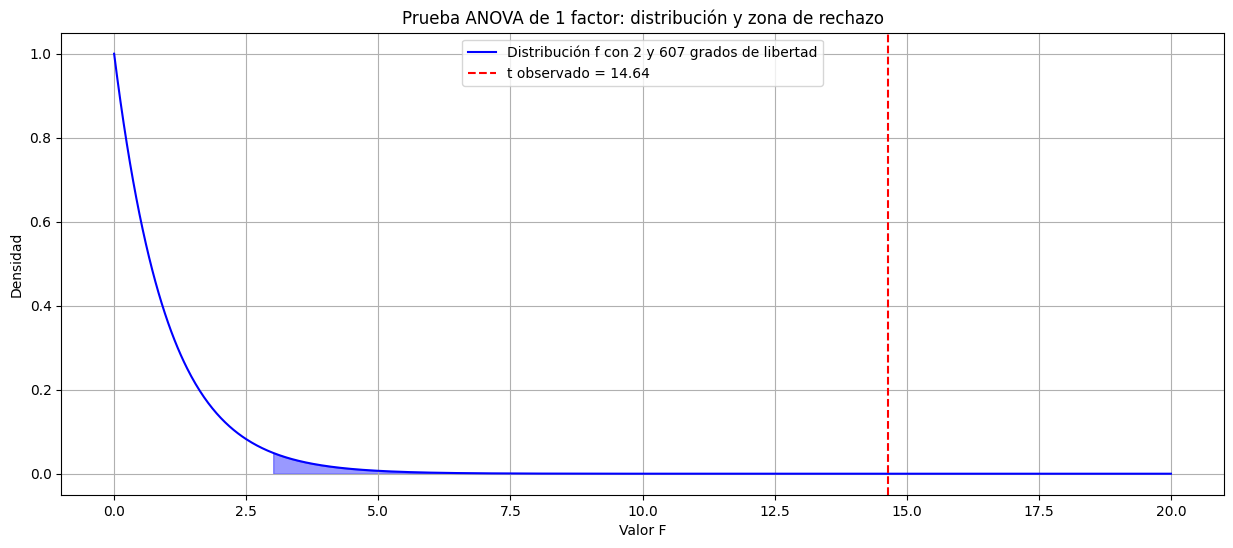

In [8]:
import matplotlib.pyplot as plt
from scipy.stats import f # La distribución f
import numpy as np

# Grados de libertad y valor de f
dof_inter = resultados.loc[0,'DF']
dof_intra = resultados.loc[1,'DF']
fval = resultados.loc[0,'F']
alpha = 0.05

# Distribución F para los "dof" obtenidos
f_vals = np.linspace(0, 20, 1000) # Recordemos que F SIEMPRE es positivo
pdf_vals = f.pdf(f_vals, dof_inter, dof_intra) # Distribución f

# Punto crítico para alfa
f_critico_der = f.ppf(1-alpha, dof_inter, dof_intra) # Recordemos que ANOVA SIEMPRE será prueba unilateral derecha

# Graficar la distribución
plt.figure(figsize=(15, 6))
plt.plot(f_vals, pdf_vals, label=f"Distribución f con {int(dof_inter)} y {int(dof_intra)} grados de libertad", color='blue')

# Zona de rechazo derecha
f_rechazo_der = np.linspace(f_critico_der, 20, 100) # Irá desde f_critico_der hasta 20, 100 datos
plt.fill_between(f_rechazo_der, f.pdf(f_rechazo_der, dof_inter, dof_intra), color='blue', alpha=0.4)

# Dibujar estadística f en la distribución anterior
plt.axvline(fval, color='red', linestyle='--', label=f't observado = {fval:.2f}')

# Etiquetas
plt.title('Prueba ANOVA de 1 factor: distribución y zona de rechazo')
plt.xlabel('Valor F')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)

### 1.8. Paso 8: aceptar o rechazar $H_0$

Y con las pruebas anteriores, incluyendo el valor p de $6.16x10^{-7}$ podemos rechazar la hipótesis nula (medias iguales) y nos inclinamos por $H_1$ (las medias son diferentes).

Y por tanto:

> Existen diferencias estadísticamente significativas en las tasas medias de conversión entre las tres campañas

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba actualizadas

En este caso "pingouin":

- Calcula $\eta^2$ pero no el tamaño F-Cohen (tendremos que calcularlo)
- No retorna la potencia de la prueba (pero la podemos calcular con "statsmodels")

Veamos cómo hacer estos cálculos. Comencemos con el tamaño del efecto F-Cohen:

In [10]:
n2 = resultados.loc[0,'n2']
f_cohen = np.sqrt(n2/(1-n2))
f_cohen

0.2196465829753836

Y ahora calculemos la potencia de la prueba con "statsmodels":

In [11]:
# Instancia
analisis = FTestAnovaPower()

# Calcular potencia
potencia = analisis.power(
    effect_size = f_cohen, # El tamaño F-Cohen que acabamos de calcular
    nobs = len(datos), # El número total de datos (combinando los tres grupos)
    alpha = alpha, # El nivel de significancia definido anteriormente para la prueba (0.05)
    k_groups = 3, # El número de subniveles del factor (el número de grupos)
)

Y ahora sí veamos el tamaño del efecto y la potencia de la prueba que acabamos de calcular:

In [12]:
print(f"Tamaño del efecto actualizado (F-Cohen): {f_cohen}")
print(f"Potencia de la prueba actualizada: {potencia}")

Tamaño del efecto actualizado (F-Cohen): 0.2196465829753836
Potencia de la prueba actualizada: 0.9990306291583696


Según la escala de Cohen:

- 0.1 es un efecto pequeño
- 0.25 es un efecto mediano
- 0.40 es un efecto grande

Lo anterior nos dice que a pesar de que se observó un efecto (p << 0.05) la magnitud de esa diferencia entre las medias es modesta (porque el tamaño del efecto es pequeño: 0.21).

Mientras que la probabilidad de detectar una diferencia real es de prácticamente el 100% (potencia de 0.999...)